In [67]:
import geopandas as gpd
import pickle
from pathlib import Path
import sys

sys.path.insert(0, '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction')
sys.path.insert(0, '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN')

from tools import *

dataset = Path('firemen/firepoint/2x2/train')
scale = '3'
graph_construct = 'risk-size-zonemeteo-degree-a3-r5-t0.3'

graph = pickle.load(open(dataset /  f'graph_{scale}_{graph_construct}_node.pkl', 'rb'))

In [68]:
graph.graph_ids.shape

(4326,)

In [69]:
graph.departements.unique()

array(['departement-01-ain', 'departement-06-alpes-maritimes',
       'departement-25-doubs', 'departement-69-rhone',
       'departement-78-yvelines'], dtype=object)

In [70]:
graph.graph_ids[mask].shape[0]

1158

<Axes: >

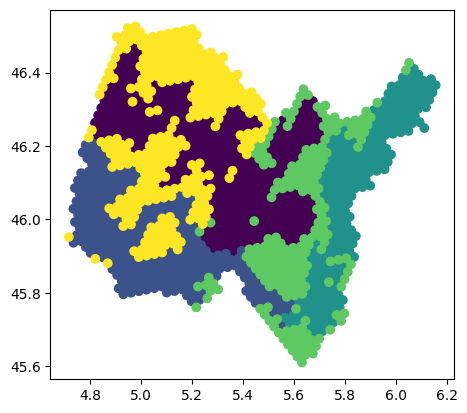

In [77]:
import pandas as pd
import numpy as np
import geopandas as gpd

departement = 'departement-01-ain'

mask = graph.departements == departement

dataframe = pd.DataFrame(index=np.arange(0, graph.graph_ids[mask].shape[0]))
dataframe['latitude'] = graph.oriLatitudes[mask].values
dataframe['longitude'] = graph.oriLongitude[mask].values
dataframe['num_zone'] = graph.graph_ids[mask]

geo = gpd.GeoDataFrame(
    dataframe,
    geometry=gpd.points_from_xy(dataframe.longitude, dataframe.latitude),
    crs="EPSG:4326"
)

geo_zone = (
    geo.groupby("num_zone", as_index=False)
       .agg(geometry=("geometry", lambda s: s.unary_union))
)

geo_zone = gpd.GeoDataFrame(geo_zone, geometry="geometry", crs=geo.crs)
geo_zone.plot(column="num_zone")

In [76]:
geo_zone.to_file("25.geojson", driver='GeoJSON')

2026-03-23 01:35:03,598 [INFO ]  Created 4 records
